In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("adult_with_headers (1).csv")

# Check shape and columns
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# Display first 5 rows
display(df.head())

Shape of dataset: (32561, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
# Feature 1: Age Group
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["Young", "Adult", "Middle_Aged", "Senior", "Elderly"],
    include_lowest=True
)

display(df[["age", "age_group"]].head(10))

,age,age_group
0,39,Middle_Aged
1,50,Middle_Aged
2,38,Middle_Aged
3,53,Senior
4,28,Adult
5,37,Middle_Aged
6,49,Middle_Aged
7,52,Senior
8,31,Adult
9,42,Middle_Aged


In [3]:
# Feature 2: Is Married
df["is_married"] = (
    df["marital_status"]
    .str.strip()
    .str.contains("Married", case=False, na=False)
    .astype(int)
)

display(df[["marital_status", "is_married"]].head(10))

,marital_status,is_married
0,Never-married,1
1,Married-civ-spouse,1
2,Divorced,0
3,Married-civ-spouse,1
4,Married-civ-spouse,1
5,Married-civ-spouse,1
6,Married-spouse-absent,1
7,Married-civ-spouse,1
8,Never-married,1
9,Married-civ-spouse,1


In [4]:
# Feature 3: Net Capital
df["capital_net"] = df["capital_gain"] - df["capital_loss"]

display(
    df[["capital_gain", "capital_loss", "capital_net"]].head(10)
)

,capital_gain,capital_loss,capital_net
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0
5,0,0,0
6,0,0,0
7,0,0,0
8,14084,0,14084
9,5178,0,5178


In [5]:
print("New Features Created:")
print("1. age_group")
print("2. is_married")
print("3. capital_net")

display(df.head())

New Features Created:
1. age_group
2. is_married
3. capital_net


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,age_group,is_married,capital_net
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Middle_Aged,1,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Middle_Aged,1,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Middle_Aged,0,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Senior,1,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Adult,1,0


In [6]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns

# Calculate skewness
skewness = df[numeric_columns].skew().sort_values(ascending=False)

print("Skewness of numerical features:")
display(skewness)

Skewness of numerical features:


capital_gain      11.953848
capital_net       11.871934
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
is_married        -1.512409
dtype: float64

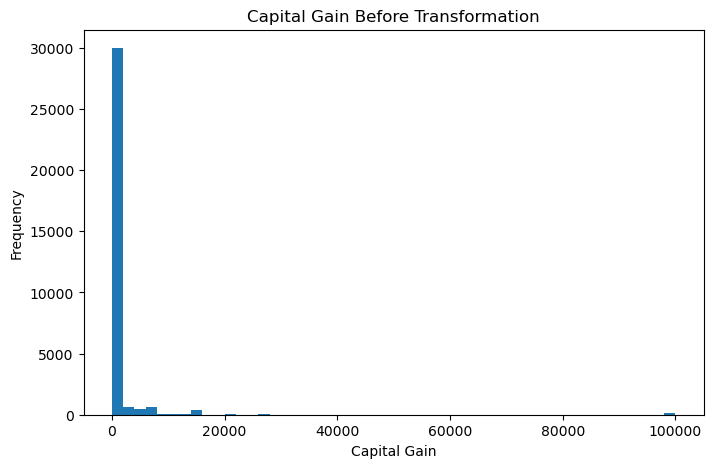

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(df["capital_gain"], bins=50)

plt.title("Capital Gain Before Transformation")
plt.xlabel("Capital Gain")
plt.ylabel("Frequency")

plt.show()

In [11]:
df["capital_gain_log"] = np.log1p(df["capital_gain"])

In [12]:
before_skewness = df["capital_gain"].skew()
after_skewness = df["capital_gain_log"].skew()

print("Skewness before transformation:", before_skewness)
print("Skewness after transformation:", after_skewness)

Skewness before transformation: 11.953847687699799
Skewness after transformation: 3.096143524467517


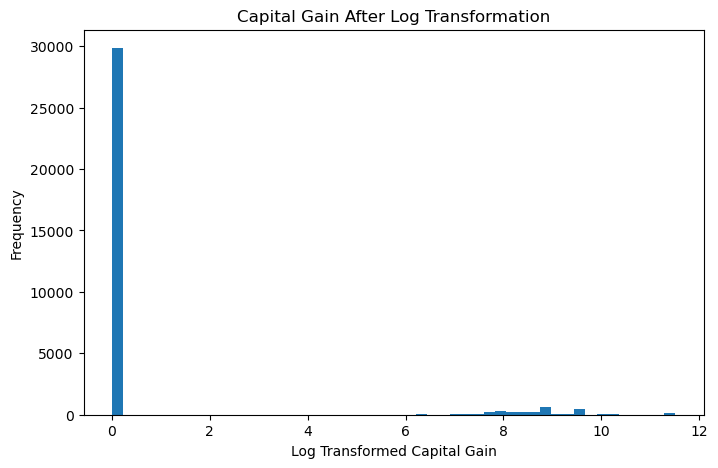

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df["capital_gain_log"], bins=50)

plt.title("Capital Gain After Log Transformation")
plt.xlabel("Log Transformed Capital Gain")
plt.ylabel("Frequency")

plt.show()

Original Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Three New Features Created:


,age,age_group,marital_status,is_married,capital_gain,capital_loss,capital_net
0,39,Middle_Aged,Never-married,1,2174,0,2174
1,50,Middle_Aged,Married-civ-spouse,1,0,0,0
2,38,Middle_Aged,Divorced,0,0,0,0
3,53,Senior,Married-civ-spouse,1,0,0,0
4,28,Adult,Married-civ-spouse,1,0,0,0
5,37,Middle_Aged,Married-civ-spouse,1,0,0,0
6,49,Middle_Aged,Married-spouse-absent,1,0,0,0
7,52,Senior,Married-civ-spouse,1,0,0,0
8,31,Adult,Never-married,1,14084,0,14084
9,42,Middle_Aged,Married-civ-spouse,1,5178,0,5178


Skewness of Numerical Features:


capital_gain      11.953848
capital_net       11.871934
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
is_married        -1.512409
dtype: float64

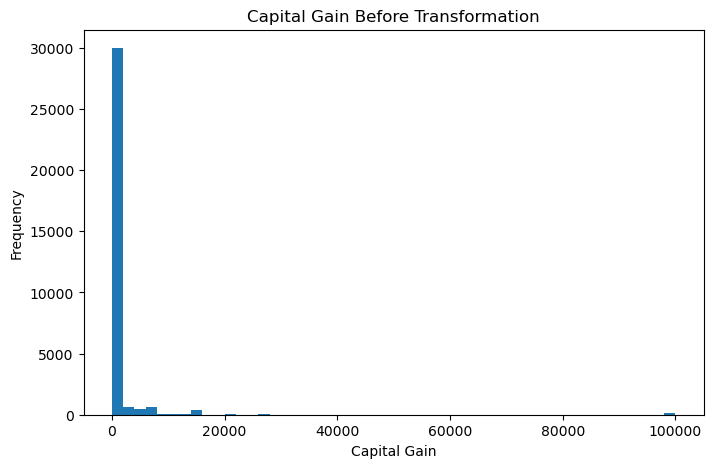

Skewness Before Transformation: 11.953847687699799
Skewness After Transformation: 3.096143524467517


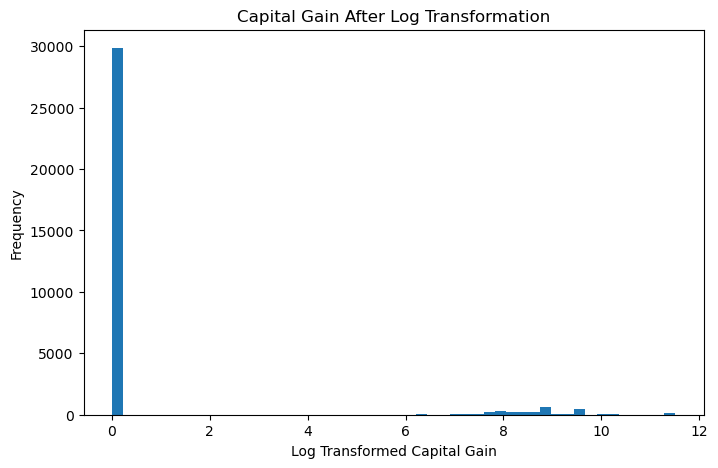

Final Dataset Shape: (32561, 19)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,age_group,is_married,capital_net,capital_gain_log
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,Middle_Aged,1,2174,7.684784
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,Middle_Aged,1,0,0.000000
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,Middle_Aged,0,0,0.000000
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,Senior,1,0,0.000000
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,Adult,1,0,0.000000


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STEP 1: LOAD DATASET
# ============================================================

df = pd.read_csv("adult_with_headers (1).csv")

print("Original Shape:", df.shape)
display(df.head())


# ============================================================
# STEP 2: CREATE FEATURE 1 - AGE GROUP
# ============================================================

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=["Young", "Adult", "Middle_Aged", "Senior", "Elderly"],
    include_lowest=True
)


# ============================================================
# STEP 3: CREATE FEATURE 2 - IS MARRIED
# ============================================================

df["is_married"] = (
    df["marital_status"]
    .str.strip()
    .str.contains("Married", case=False, na=False)
    .astype(int)
)


# ============================================================
# STEP 4: CREATE FEATURE 3 - NET CAPITAL
# ============================================================

df["capital_net"] = (
    df["capital_gain"] - df["capital_loss"]
)


# ============================================================
# STEP 5: DISPLAY NEW FEATURES
# ============================================================

print("Three New Features Created:")

display(
    df[
        [
            "age",
            "age_group",
            "marital_status",
            "is_married",
            "capital_gain",
            "capital_loss",
            "capital_net"
        ]
    ].head(10)
)


# ============================================================
# STEP 6: CHECK SKEWNESS
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

skewness = df[numeric_columns].skew().sort_values(
    ascending=False
)

print("Skewness of Numerical Features:")
display(skewness)


# ============================================================
# STEP 7: VISUALIZE CAPITAL_GAIN BEFORE TRANSFORMATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(df["capital_gain"], bins=50)

plt.title("Capital Gain Before Transformation")
plt.xlabel("Capital Gain")
plt.ylabel("Frequency")

plt.show()


# ============================================================
# STEP 8: LOG TRANSFORMATION
# ============================================================

df["capital_gain_log"] = np.log1p(
    df["capital_gain"]
)


# ============================================================
# STEP 9: COMPARE SKEWNESS
# ============================================================

before_skewness = df["capital_gain"].skew()
after_skewness = df["capital_gain_log"].skew()

print("Skewness Before Transformation:",
      before_skewness)

print("Skewness After Transformation:",
      after_skewness)


# ============================================================
# STEP 10: VISUALIZE AFTER TRANSFORMATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(df["capital_gain_log"], bins=50)

plt.title("Capital Gain After Log Transformation")
plt.xlabel("Log Transformed Capital Gain")
plt.ylabel("Frequency")

plt.show()


# ============================================================
# STEP 11: FINAL DATASET
# ============================================================

print("Final Dataset Shape:", df.shape)

display(df.head())